<a href="https://colab.research.google.com/github/praneel1/gridlock/blob/main/flipgrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
!pip install gdown

In [40]:
import gdown
import zipfile
gdown.download(id="1GEKvKC0W38jpaVcKgd0NuB-9cEA-JPF_", output="data.zip", quiet=False)
with zipfile.ZipFile("data.zip") as z:
    z.extractall("data")

Downloading...
From: https://drive.google.com/uc?id=1GEKvKC0W38jpaVcKgd0NuB-9cEA-JPF_
To: /content/data.zip
100%|██████████| 2.82M/2.82M [00:00<00:00, 27.2MB/s]


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [42]:
df = pd.read_csv("/content/data/dataset/train.csv")
df.head(10)

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy
5,5,qp02zw,48,0:0,0.016262,Residential,2,Not Allowed,Yes,8.446025,Rainy
6,6,qp02zy,48,0:0,0.042247,Residential,3,Allowed,Yes,15.772408,Foggy
7,7,qp08by,48,0:0,0.040135,Residential,1,Not Allowed,No,2.705143,Snowy
8,8,qp08gq,48,0:0,0.001002,Residential,1,Not Allowed,No,18.136899,Foggy
9,9,qp08gy,48,0:0,0.003948,Residential,3,Allowed,Yes,12.738209,Rainy


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [44]:
df.isnull().sum()

,0
Index,0
geohash,0
day,0
timestamp,0
demand,0
RoadType,600
NumberofLanes,0
LargeVehicles,0
Landmarks,0
Temperature,2495


In [45]:
df["RoadType"] = df["RoadType"].fillna("Unknown")
df["Weather"] = df["Weather"].fillna("Unknown")
df["Temperature"] = df["Temperature"].fillna(df["Temperature"].mode())

In [46]:
df.sample(5)

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
6818,6818,qp03xz,48,2:0,0.231413,Street,1,Not Allowed,Yes,20.060393,Sunny
69706,69706,qp03ry,49,0:0,0.342823,Street,1,Not Allowed,Yes,12.560347,Rainy
22585,22585,qp08gr,48,6:30,0.031666,Residential,2,Not Allowed,Yes,19.979039,Sunny
62231,62231,qp03pw,48,21:0,0.009069,Residential,2,Not Allowed,Yes,10.918127,Rainy
59995,59995,qp09d8,48,19:15,0.271127,Street,1,Not Allowed,Yes,23.777193,Sunny


In [47]:
df["hour"] = df["timestamp"].apply(lambda x: int(x.split(":")[0]))
df["minute"] = df["timestamp"].apply(lambda x: int(x.split(":")[1]))
df["total_minutes"] = df["hour"] * 60 + df["minute"]

`time_sin` = $\sin(\frac{2 .\pi. {total\_min}}{1400})$ \
`time_cos` = $\cos(\frac{2 .\pi. {total\_min}}{1400})$

In [48]:
df["time_sin"] = np.sin(2 * np.pi * df["total_minutes"] / 1440)
df["time_cos"] = np.cos(2 * np.pi * df["total_minutes"] / 1440)

In [49]:
!pip install pygeohash

In [50]:
import pygeohash as pgh

df["latitude"] = df["geohash"].apply(lambda x: pgh.decode(x)[0])
df["longitude"] = df["geohash"].apply(lambda x: pgh.decode(x)[1])

# Splitting Day 48 as trainset, Day 49 as testset

In [51]:
train_df = df[df["day"] == 48].copy()
test_df = df[df["day"] == 49].copy()

## Average Demand over time

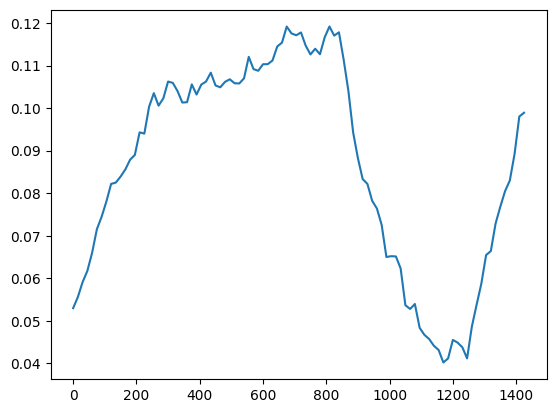

In [52]:
mean_demand = train_df.groupby("total_minutes")["demand"].mean()
plt.plot(mean_demand)

## Demand Variance over time

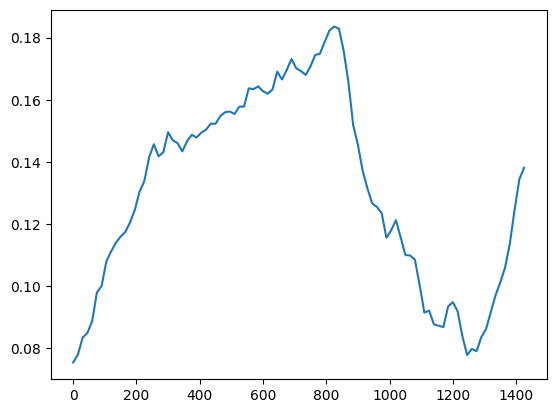

In [53]:
std_demand = train_df.groupby("total_minutes")["demand"].std()
plt.plot(std_demand)

<Axes: xlabel='geohash'>

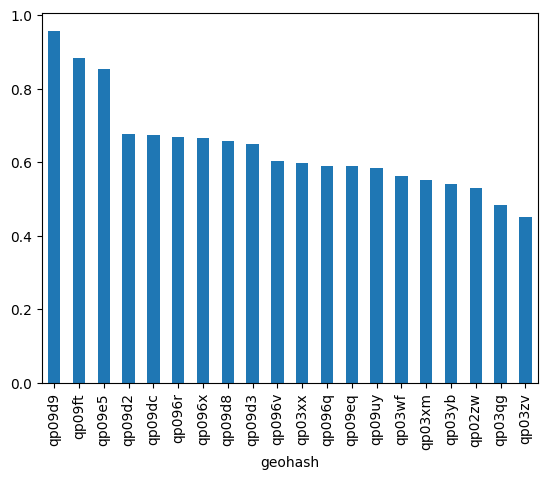

In [54]:
# @title
top_geohashes = train_df.groupby("geohash")["demand"].mean().sort_values(ascending=False).head(20)
top_geohashes.plot(kind="bar")

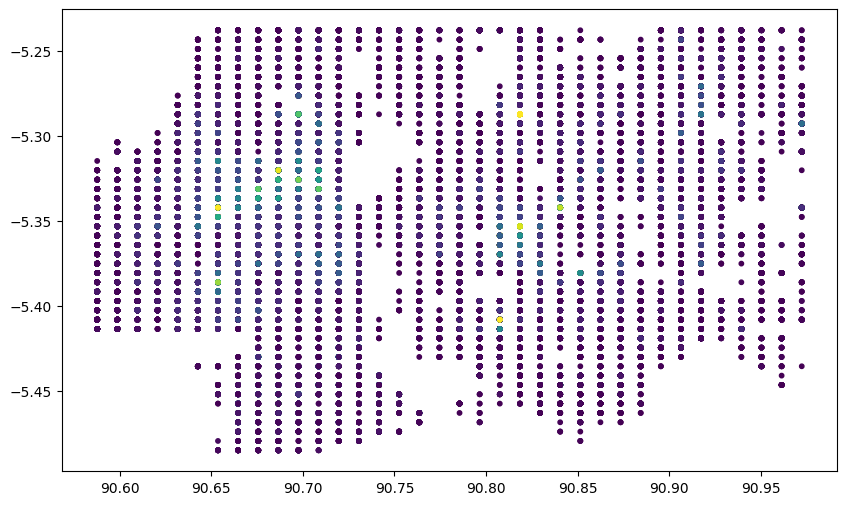

In [55]:
# @title
plt.figure(figsize=(10,6))
plt.scatter(train_df["longitude"], train_df["latitude"], c=train_df["demand"], s=10)

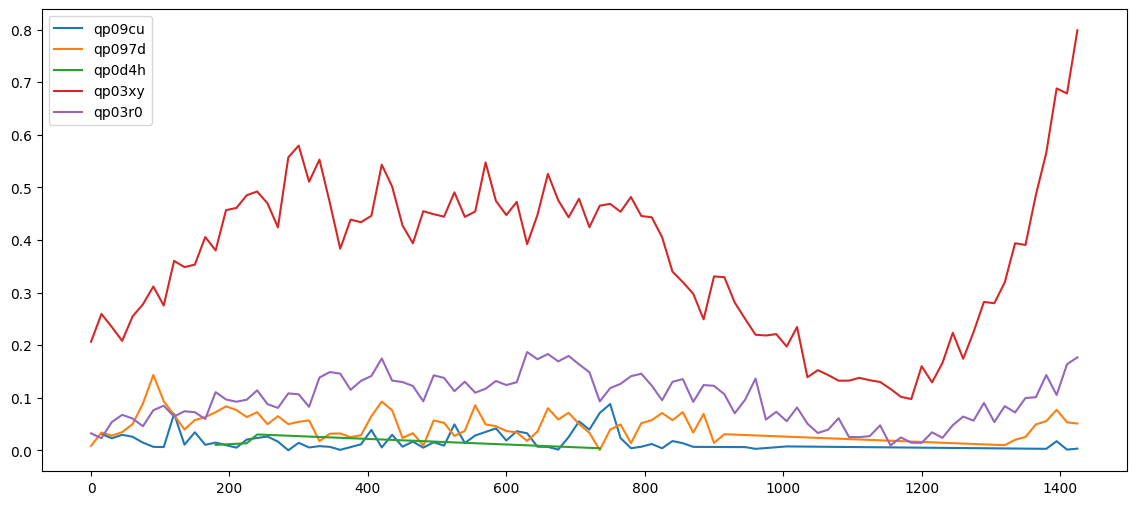

In [56]:
# @title
random_geohash = train_df['geohash'].sample(5).drop_duplicates()
plt.figure(figsize=(14,6))
for geohash in random_geohash:
    df_geohash = train_df[train_df['geohash'] == geohash]
    plt.plot(df_geohash['total_minutes'], df_geohash['demand'], label=geohash)
plt.legend()
plt.show()

## Demand Distribution

<Axes: xlabel='demand', ylabel='Count'>

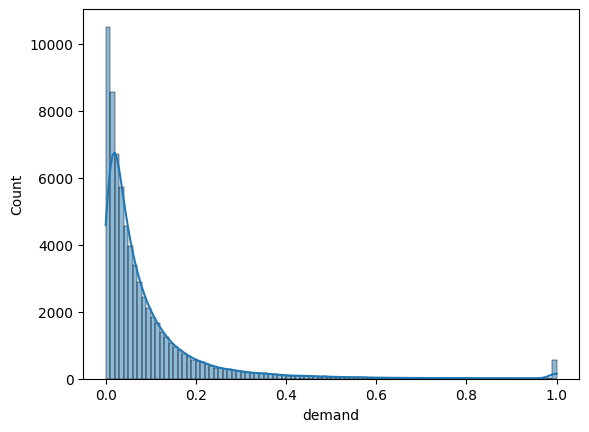

In [57]:
sns.histplot(train_df["demand"], bins=100, kde=True)


<Axes: xlabel='demand', ylabel='Count'>

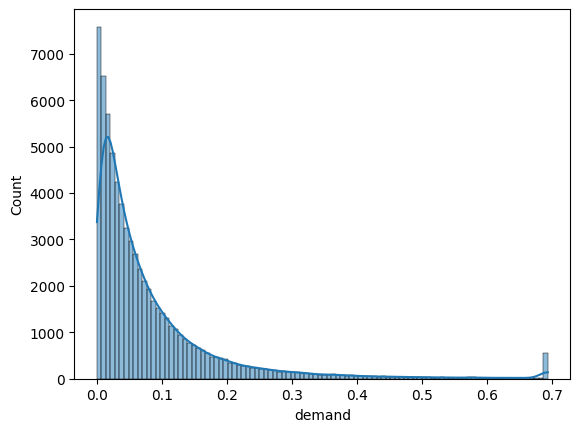

In [58]:
sns.histplot(np.log1p(train_df["demand"]), bins=100, kde=True)

Out of 1241 geohashes, only 383 geohashes have 80 or more timestamps

In [59]:
# @title
coverage = train_df["geohash"].value_counts()
coverage.count(),coverage[coverage <1].count()

(np.int64(1241), np.int64(0))

In [60]:
df = df.sort_values(by=["geohash", "day", "total_minutes"])

In [61]:
df["lag_1"] = df.groupby("geohash")["demand"].shift(1)
df["lag_2"] = df.groupby("geohash")["demand"].shift(2)
df["lag_3"] = df.groupby("geohash")["demand"].shift(3)
df["lag_4"] = df.groupby("geohash")["demand"].shift(4)
df["rolling_mean_4"] = df.groupby("geohash")["demand"].transform(lambda x: x.shift(1).rolling(4).mean())
df["ewm_mean"] = df.groupby("geohash")["demand"].transform(lambda x: x.shift(1).ewm(alpha=0.3).mean())
df = df.dropna()

In [62]:
df.head(10)

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,...,time_sin,time_cos,latitude,longitude,lag_1,lag_2,lag_3,lag_4,rolling_mean_4,ewm_mean
22536,22536,qp02yc,48,6:30,0.008387,Residential,1,Not Allowed,No,11.435670,...,0.991445,-0.130526,-5.484924,90.653687,0.026422,0.025961,0.012944,0.005397,0.017681,0.020840
23453,23453,qp02yc,48,6:45,0.020780,Residential,2,Not Allowed,Yes,19.681691,...,0.980785,-0.195090,-5.484924,90.653687,0.008387,0.026422,0.025961,0.012944,0.018429,0.016350
24356,24356,qp02yc,48,7:0,0.004853,Residential,2,Not Allowed,Yes,7.513305,...,0.965926,-0.258819,-5.484924,90.653687,0.020780,0.008387,0.026422,0.025961,0.020388,0.017856
25265,25265,qp02yc,48,7:15,0.027092,Residential,2,Not Allowed,Yes,13.315576,...,0.946930,-0.321439,-5.484924,90.653687,0.004853,0.020780,0.008387,0.026422,0.015111,0.013605
26146,26146,qp02yc,48,7:30,0.004824,Residential,1,Not Allowed,No,19.849524,...,0.923880,-0.382683,-5.484924,90.653687,0.027092,0.004853,0.020780,0.008387,0.015278,0.017899
31432,31432,qp02yc,48,9:0,0.017362,Residential,3,Allowed,Yes,26.872314,...,0.707107,-0.707107,-5.484924,90.653687,0.004824,0.027092,0.004853,0.020780,0.014387,0.013811
36776,36776,qp02yc,48,10:30,0.046790,Residential,1,Not Allowed,No,22.809028,...,0.382683,-0.923880,-5.484924,90.653687,0.017362,0.004824,0.027092,0.004853,0.013533,0.014908
37683,37683,qp02yc,48,10:45,0.021158,Residential,1,Not Allowed,No,16.543659,...,0.321439,-0.946930,-5.484924,90.653687,0.046790,0.017362,0.004824,0.027092,0.024017,0.024665
15260,15260,qp02yz,48,4:30,0.018470,Residential,3,Allowed,Yes,-0.398511,...,0.923880,0.382683,-5.451965,90.653687,0.012700,0.011198,0.013286,0.019280,0.014116,0.013289
16182,16182,qp02yz,48,4:45,0.039162,Residential,3,Allowed,Yes,10.622391,...,0.946930,0.321439,-5.451965,90.653687,0.018470,0.012700,0.011198,0.013286,0.013914,0.015157


In [63]:
train_df = df[df["day"] == 48]
test_df = df[df["day"] == 49]
train_df = train_df.copy()
test_df = test_df.copy()

In [64]:
from sklearn.preprocessing import OrdinalEncoder
categorical_columns = ["RoadType", "LargeVehicles", "Landmarks","Weather"]
encoder = OrdinalEncoder()
train_df[categorical_columns] = encoder.fit_transform(train_df[categorical_columns])
test_df[categorical_columns] = encoder.transform(test_df[categorical_columns])

In [116]:
features = [
    "hour",
    "minute",
    "total_minutes",

    "time_sin",
    "time_cos",

    "RoadType",
    "NumberofLanes",
    "LargeVehicles",
    "Landmarks",
    "Temperature",
    "Weather",

    "latitude",
    "longitude",

    "lag_1",
    "lag_2",
    "lag_4",

    "rolling_mean_4",

    "ewm_mean"
]

X_train = train_df[features]
y_train = train_df["demand"]

X_test = test_df[features]
y_test = test_df["demand"]

In [89]:
!pip install catboost

In [148]:
from catboost import CatBoostRegressor
model = CatBoostRegressor(iterations=1000, learning_rate=0.05, max_depth=8, verbose=False)
model.fit(X_train, y_train)

CatBoostRegressor(iterations=1000, learning_rate=0.05, loss_function='RMSE', max_depth=8, verbose=False)

In [131]:
from xgboost import XGBRegressor
model2 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=7
)
model2.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [149]:
from sklearn.metrics import r2_score
import math
predictions = model.predict(X_test)
score = max(0, 100*r2_score(y_test, predictions))
score

94.8869481202282

In [133]:
pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

,0
RoadType,0.905143
lag_1,0.066423
rolling_mean_4,0.008701
LargeVehicles,0.005553
ewm_mean,0.004382
lag_2,0.003602
time_sin,0.000850
time_cos,0.000750
Landmarks,0.000691
NumberofLanes,0.000651


In [134]:
train_df.groupby("RoadType")["demand"].describe()

,count,mean,std,min,25%,50%,75%,max
RoadType,,,,,,,,
0.0,3075.0,0.617625,0.233293,3.500089e-01,0.416403,0.531119,0.822478,1.000000
1.0,57767.0,0.058467,0.052142,6.245650e-07,0.017234,0.042146,0.086095,0.219997
2.0,3338.0,0.273090,0.036852,2.200224e-01,0.240490,0.267968,0.302041,0.349908
3.0,502.0,0.099034,0.141241,1.965464e-04,0.018343,0.050655,0.113133,1.000000


In [150]:
tdf = pd.read_csv('/content/data/dataset/test.csv')

In [151]:
tdf["RoadType"] = tdf["RoadType"].fillna("Unknown")
tdf["Weather"] = tdf["Weather"].fillna("Unknown")
tdf["Temperature"] = tdf["Temperature"].fillna(tdf["Temperature"].median())

In [152]:
tdf["hour"] = tdf["timestamp"].apply(lambda x: int(x.split(":")[0]))
tdf["minute"] = tdf["timestamp"].apply(lambda x: int(x.split(":")[1]))
tdf["total_minutes"] = tdf["hour"] * 60 + tdf["minute"]

In [153]:
tdf["time_sin"] = np.sin(2 * np.pi * tdf["total_minutes"] / 1440)
tdf["time_cos"] = np.cos(2 * np.pi * tdf["total_minutes"] / 1440)
tdf["latitude"] = tdf["geohash"].apply(lambda x: pgh.decode(x)[0])
tdf["longitude"] = tdf["geohash"].apply(lambda x: pgh.decode(x)[1])

In [154]:
tdf[categorical_columns] = encoder.transform(tdf[categorical_columns])

In [155]:
history_dict = {}

for geohash, group in df.groupby("geohash"):

    history_dict[geohash] = (
        group.sort_values(
            by=["day", "total_minutes"]
        )["demand"].tolist()
    )

In [157]:
predictions = []

for idx in range(len(tdf)):

    row = tdf.iloc[idx]

    geohash = row["geohash"]

    history = history_dict.get(
        geohash,
        []
    )

    if len(history) < 4:
        predictions.append(0)
        continue

    lag_1 = history[-1]
    lag_2 = history[-2]
    lag_4 = history[-4]

    rolling_mean_4 = np.mean(
        history[-4:]
    )

    rolling_std_4 = np.std(
        history[-4:]
    )

    ewm_mean = pd.Series(history).ewm(
        alpha=0.3
    ).mean().iloc[-1]

    row_features = row.copy()

    row_features["lag_1"] = lag_1
    row_features["lag_2"] = lag_2
    row_features["lag_4"] = lag_4
    row_features["rolling_mean_4"] = rolling_mean_4
    row_features["rolling_std_4"] = rolling_std_4
    row_features["ewm_mean"] = ewm_mean

    X_row = pd.DataFrame(
    [row_features[features].values],
    columns=features
    )
    X_row = X_row.astype(float)
    prediction = model.predict(X_row)[0]

    predictions.append(prediction)

    history.append(prediction)

    history_dict[geohash] = history

In [158]:
submission = pd.DataFrame({
    "Index": tdf["Index"],
    "demand": predictions
})
submission.to_csv(
    "submission.csv",
    index=False
)

In [111]:
df.head(10)[['demand', 'lag_1', 'lag_2']]

,demand,lag_1,lag_2
22536,0.008387,0.026422,0.025961
23453,0.020780,0.008387,0.026422
24356,0.004853,0.020780,0.008387
25265,0.027092,0.004853,0.020780
26146,0.004824,0.027092,0.004853
31432,0.017362,0.004824,0.027092
36776,0.046790,0.017362,0.004824
37683,0.021158,0.046790,0.017362
15260,0.018470,0.012700,0.011198
16182,0.039162,0.018470,0.012700
